## Setup
Define the time set (0–23), the two companies, hourly costs, demand values, and the shift-coverage set `Q`. Then set the solver to Gurobi.


In [31]:
import pyomo.environ as pyo
import pandas as pd

I = list(range(24))
J = [1, 2]

C = {
    0:189, 1:189, 2:189, 3:180, 4:171, 5:162, 6:153, 7:144, 8:135, 9:126, 10:126, 11:135,
    12:144, 13:153, 14:162, 15:171, 16:180, 17:189, 18:189, 19:189, 20:189, 21:189, 22:189, 23:189
}

D_hour = {
    0:  {1: 120, 2: 70},
    1:  {1: 95,  2: 40},
    2:  {1: 90,  2: 20},
    3:  {1: 50,  2: 30},
    4:  {1: 30,  2: 50},
    5:  {1: 30,  2: 40},
    6:  {1: 60,  2: 40},
    7:  {1: 110, 2: 90},
    8:  {1: 140, 2: 110},
    9:  {1: 200, 2: 110},
    10: {1: 180, 2: 110},
    11: {1: 180, 2: 130},
    12: {1: 240, 2: 150},
    13: {1: 220, 2: 160},
    14: {1: 220, 2: 120},
    15: {1: 230, 2: 130},
    16: {1: 250, 2: 160},
    17: {1: 260, 2: 180},
    18: {1: 230, 2: 200},
    19: {1: 250, 2: 170},
    20: {1: 260, 2: 140},
    21: {1: 250, 2: 110},
    22: {1: 220, 2: 100},
    23: {1: 190, 2: 90},
}

D = {(i, j): int(D_hour[i][j]) for i in I for j in J}

def mod24(x: int) -> int:
    return x % 24

Q = {i: [mod24(i-6), mod24(i-5), mod24(i-4), mod24(i-2), mod24(i-1), mod24(i)] for i in I}

solver_name = "gurobi"
Solver = pyo.SolverFactory(solver_name)
if not Solver.available():
    raise RuntimeError(f"Solver '{solver_name}' is not available.")


## Model definition (Pyomo)
Build the Pyomo model, define decision variables `x` (shift starts) and `L` (unmet demand), and write the cost + penalty objective.


In [32]:
m = pyo.ConcreteModel()

m.I = pyo.RangeSet(0, 23)
m.J = pyo.Set(initialize=[1, 2])

m.C = pyo.Param(m.I, initialize=C)
m.D = pyo.Param(m.I, m.J, initialize=lambda mm, i, j: D[(i, j)])
m.Q = pyo.Set(m.I, initialize=lambda mm, i: Q[i], within=m.I)

m.x = pyo.Var(m.I, m.J, domain=pyo.NonNegativeIntegers, bounds=(0, 100))
m.L = pyo.Var(m.I, m.J, domain=pyo.NonNegativeIntegers, bounds=(0, 10))

def obj_rule(mm):
    wage = sum(mm.x[i, j] * mm.C[i] for i in mm.I for j in mm.J)
    pen_L1_mid = 60 * sum(mm.L[i, 1] for i in range(7, 18))
    pen_L1_other = 30 * (sum(mm.L[i, 1] for i in range(0, 7)) + sum(mm.L[i, 1] for i in range(18, 24)))
    pen_L2 = 45 * sum(mm.L[i, 2] for i in mm.I)
    return wage + pen_L1_mid + pen_L1_other + pen_L2

m.obj = pyo.Objective(rule=obj_rule, sense=pyo.minimize)


## Constraints
Add hiring limits, working-capacity limits, demand coverage with shortage variables, shortage caps, and the minimum work requirement.


In [33]:
def cap_hire_rule(mm, i):
    return sum(mm.x[i, j] for j in mm.J) <= 100
m.cap_hire = pyo.Constraint(m.I, rule=cap_hire_rule)

def cap_work_rule(mm, i):
    return sum(mm.x[k, j] for k in mm.Q[i] for j in mm.J) <= 420
m.cap_work = pyo.Constraint(m.I, rule=cap_work_rule)

def shortage_rule(mm, i, j):
    return mm.D[i, j] - sum(mm.x[k, j] for k in mm.Q[i]) <= mm.L[i, j]
m.shortage = pyo.Constraint(m.I, m.J, rule=shortage_rule)

def L_cap_rule(mm, i, j):
    return mm.L[i, j] <= 10
m.L_cap = pyo.Constraint(m.I, m.J, rule=L_cap_rule)

m.sum_L1 = pyo.Constraint(expr=sum(m.L[i, 1] for i in m.I) <= 40)
m.sum_L2 = pyo.Constraint(expr=sum(m.L[i, 2] for i in m.I) <= 30)

def min_work_rule(mm, i):
    return sum(mm.x[k, j] for k in mm.Q[i] for j in mm.J) >= 80
m.min_work = pyo.Constraint(m.I, rule=min_work_rule)


## Solve (MIP) and report
Solve the integer model with Gurobi and print the hourly `x` and `L` values. The optimal objective is **z\* = 184848.0**.


In [34]:
res = Solver.solve(m, tee=False)

z_star = pyo.value(m.obj)
print("z* =", z_star)

rows = []
for i in range(24):
    rows.append({
        "hour": i,
        "x_i_1": int(round(pyo.value(m.x[i, 1]))),
        "x_i_2": int(round(pyo.value(m.x[i, 2]))),
        "L_i_1": int(round(pyo.value(m.L[i, 1]))),
        "L_i_2": int(round(pyo.value(m.L[i, 2]))),
    })
sol_df = pd.DataFrame(rows)
display(sol_df)

print("Sum L1 =", sol_df["L_i_1"].sum())
print("Sum L2 =", sol_df["L_i_2"].sum())

def build_model():
    mm = pyo.ConcreteModel()
    mm.I = pyo.RangeSet(0, 23)
    mm.J = pyo.Set(initialize=[1, 2])
    mm.C = pyo.Param(mm.I, initialize=C)
    mm.D = pyo.Param(mm.I, mm.J, initialize=lambda m_, i, j: D[(i, j)])
    mm.Q = pyo.Set(mm.I, initialize=lambda m_, i: Q[i], within=mm.I)

    mm.x = pyo.Var(mm.I, mm.J, domain=pyo.NonNegativeIntegers, bounds=(0, 100))
    mm.L = pyo.Var(mm.I, mm.J, domain=pyo.NonNegativeIntegers, bounds=(0, 10))

    def obj_rule2(m_):
        wage = sum(m_.x[i, j] * m_.C[i] for i in m_.I for j in m_.J)
        pen_L1_mid = 60 * sum(m_.L[i, 1] for i in range(7, 18))
        pen_L1_other = 30 * (sum(m_.L[i, 1] for i in range(0, 7)) + sum(m_.L[i, 1] for i in range(18, 24)))
        pen_L2 = 45 * sum(m_.L[i, 2] for i in m_.I)
        return wage + pen_L1_mid + pen_L1_other + pen_L2

    mm.obj = pyo.Objective(rule=obj_rule2, sense=pyo.minimize)

    mm.cap_hire = pyo.Constraint(mm.I, rule=lambda m_, i: sum(m_.x[i, j] for j in mm.J) <= 100)
    mm.cap_work = pyo.Constraint(mm.I, rule=lambda m_, i: sum(m_.x[k, j] for k in mm.Q[i] for j in mm.J) <= 420)
    mm.shortage = pyo.Constraint(mm.I, mm.J, rule=lambda m_, i, j: mm.D[i, j] - sum(mm.x[k, j] for k in mm.Q[i]) <= mm.L[i, j])
    mm.L_cap = pyo.Constraint(mm.I, mm.J, rule=lambda m_, i, j: mm.L[i, j] <= 10)
    mm.sum_L1 = pyo.Constraint(expr=sum(mm.L[i, 1] for i in mm.I) <= 40)
    mm.sum_L2 = pyo.Constraint(expr=sum(mm.L[i, 2] for i in mm.I) <= 30)
    mm.min_work = pyo.Constraint(mm.I, rule=lambda m_, i: sum(mm.x[k, j] for k in mm.Q[i] for j in mm.J) >= 80)

    return mm

x_star = {(i, j): int(round(pyo.value(m.x[i, j]))) for i in range(24) for j in [1, 2]}
L_star = {(i, j): int(round(pyo.value(m.L[i, j]))) for i in range(24) for j in [1, 2]}

candidates = [("x", 12, 1), ("x", 12, 2), ("x", 17, 1), ("x", 17, 2), ("L", 12, 1), ("L", 12, 2)]
multiple = False

for typ, i, j in candidates:
    mm = build_model()
    mm.fix_opt = pyo.Constraint(expr=mm.obj.expr <= z_star + 1e-6)

    v = mm.x[i, j] if typ == "x" else mm.L[i, j]
    v0 = x_star[(i, j)] if typ == "x" else L_star[(i, j)]

    mm.obj.deactivate()
    mm.sec = pyo.Objective(expr=v, sense=pyo.maximize)
    Solver.solve(mm, tee=False)
    vmax = pyo.value(v)
    if vmax > v0 + 1e-9:
        multiple = True
        break

    mm.sec.deactivate()
    mm.sec2 = pyo.Objective(expr=v, sense=pyo.minimize)
    Solver.solve(mm, tee=False)
    vmin = pyo.value(v)
    if vmin < v0 - 1e-9:
        multiple = True
        break

print("Multiple optimal solutions:", "YES" if multiple else "NO (not detected)")


z* = 184848.0


,hour,x_i_1,x_i_2,L_i_1,L_i_2
0,0,6,4,0,0
1,1,0,3,2,7
2,2,0,0,0,0
3,3,0,14,0,0
4,4,0,22,0,0
5,5,31,0,0,0
6,6,23,30,0,0
7,7,56,43,0,0
8,8,61,1,0,0
9,9,52,30,0,0


Sum L1 = 40
Sum L2 = 28
Multiple optimal solutions: YES


## Multiple optimal solutions check
Keep the optimal objective fixed and re-solve with secondary objectives (maximize/minimize a few variables). Result: **multiple optimal solutions = YES**.


In [35]:
m_lp = pyo.ConcreteModel()

m_lp.I = pyo.RangeSet(0, 23)
m_lp.J = pyo.Set(initialize=[1, 2])

m_lp.C = pyo.Param(m_lp.I, initialize=C)
m_lp.D = pyo.Param(m_lp.I, m_lp.J, initialize=lambda mm, i, j: D[(i, j)])
m_lp.Q = pyo.Set(m_lp.I, initialize=lambda mm, i: Q[i], within=m_lp.I)

m_lp.x = pyo.Var(m_lp.I, m_lp.J, domain=pyo.NonNegativeReals, bounds=(0, 100))
m_lp.L = pyo.Var(m_lp.I, m_lp.J, domain=pyo.NonNegativeReals, bounds=(0, 10))

def obj_rule_lp(mm):
    wage = sum(mm.x[i, j] * mm.C[i] for i in mm.I for j in mm.J)
    pen_L1_mid = 60 * sum(mm.L[i, 1] for i in range(7, 18))
    pen_L1_other = 30 * (sum(mm.L[i, 1] for i in range(0, 7)) + sum(mm.L[i, 1] for i in range(18, 24)))
    pen_L2 = 45 * sum(mm.L[i, 2] for i in mm.I)
    return wage + pen_L1_mid + pen_L1_other + pen_L2

m_lp.obj = pyo.Objective(rule=obj_rule_lp, sense=pyo.minimize)

m_lp.cap_hire = pyo.Constraint(m_lp.I, rule=lambda mm, i: sum(mm.x[i, j] for j in mm.J) <= 100)
m_lp.cap_work = pyo.Constraint(m_lp.I, rule=lambda mm, i: sum(mm.x[k, j] for k in mm.Q[i] for j in mm.J) <= 420)
m_lp.shortage = pyo.Constraint(m_lp.I, m_lp.J, rule=lambda mm, i, j: mm.D[i, j] - sum(mm.x[k, j] for k in mm.Q[i]) <= mm.L[i, j])
m_lp.L_cap = pyo.Constraint(m_lp.I, m_lp.J, rule=lambda mm, i, j: mm.L[i, j] <= 10)
m_lp.sum_L1 = pyo.Constraint(expr=sum(m_lp.L[i, 1] for i in m_lp.I) <= 40)
m_lp.sum_L2 = pyo.Constraint(expr=sum(m_lp.L[i, 2] for i in m_lp.I) <= 30)
m_lp.min_work = pyo.Constraint(m_lp.I, rule=lambda mm, i: sum(mm.x[k, j] for k in mm.Q[i] for j in mm.J) >= 80)


## Solve LP
Solve the LP model to enable sensitivity reporting. LP objective: **184811.6667**.


In [36]:
SolverSA = pyo.SolverFactory("gurobi_persistent")
if not SolverSA.available():
    raise RuntimeError("gurobi_persistent is not available.")

SolverSA.set_instance(m_lp)
SolverSA.solve(tee=False)

print("LP objective =", pyo.value(m_lp.obj))


LP objective = 184811.66666666663


## Sensitivity report
Extract objective-coefficient ranges (SAObjLow/SAObjUp) and RHS ranges (SARHSLow/SARHSUp) and display them as tables.


In [37]:
var_map = SolverSA._pyomo_var_to_solver_var_map

rows_vars = []
for v in m_lp.component_data_objects(pyo.Var, active=True):
    gv = var_map[v]
    rows_vars.append({
        "var": v.name,
        "value": float(v.value) if v.value is not None else None,
        "obj": float(gv.Obj),
        "rc": float(gv.RC),
        "sa_obj_low": float(gv.SAObjLow),
        "sa_obj_up": float(gv.SAObjUp),
    })

df_sa_obj = pd.DataFrame(rows_vars).sort_values("var").reset_index(drop=True)
display(df_sa_obj)


,var,value,obj,rc,sa_obj_low,sa_obj_up
0,"L[0,1]",0.000000,30.0,47.000000,-17.000000,inf
1,"L[0,2]",0.000000,45.0,61.666667,-16.666667,inf
2,"L[1,1]",3.333333,30.0,0.000000,27.000000,38.0
3,"L[1,2]",8.950617,45.0,0.000000,45.000000,45.0
4,"L[10,1]",0.000000,60.0,74.000000,-14.000000,inf
...,...,...,...,...,...,...
91,"x[7,2]",44.382716,144.0,0.000000,144.000000,144.0
92,"x[8,1]",56.790123,135.0,0.000000,135.000000,135.0
93,"x[8,2]",2.283951,135.0,0.000000,135.000000,135.0
94,"x[9,1]",48.641975,126.0,0.000000,126.000000,126.0


## Parameter sweeps
Build a sweep model where one objective coefficient and one RHS can be changed to see how the optimal objective reacts.


In [38]:
con_map = SolverSA._pyomo_con_to_solver_con_map

rows_cons = []
for c in m_lp.component_data_objects(pyo.Constraint, active=True):
    if c.equality:
        continue
    gc = con_map[c]
    rows_cons.append({
        "constr": c.name,
        "sense": gc.Sense,
        "rhs": float(gc.RHS),
        "slack": float(gc.Slack),
        "pi": float(gc.Pi),
        "sa_rhs_low": float(gc.SARHSLow),
        "sa_rhs_up": float(gc.SARHSUp),
    })

df_sa_rhs = pd.DataFrame(rows_cons).sort_values("constr").reset_index(drop=True)
display(df_sa_rhs)


,constr,sense,rhs,slack,pi,sa_rhs_low,sa_rhs_up
0,"L_cap[0,1]",<,10.0,10.000000,0.000000,0.000000,inf
1,"L_cap[0,2]",<,10.0,10.000000,0.000000,0.000000,inf
2,"L_cap[1,1]",<,10.0,6.666667,0.000000,3.333333,inf
3,"L_cap[1,2]",<,10.0,1.049383,0.000000,8.950617,inf
4,"L_cap[10,1]",<,10.0,10.000000,0.000000,0.000000,inf
...,...,...,...,...,...,...,...
165,"shortage[8,2]",<,-110.0,0.000000,-12.000000,-110.000000,-109.444444
166,"shortage[9,1]",<,-200.0,0.000000,-41.000000,-201.041667,-194.393939
167,"shortage[9,2]",<,-110.0,0.000000,-14.666667,-110.337838,-108.013699
168,sum_L1,<,40.0,0.000000,-17.000000,36.711712,40.641026


## Sweep: objective coefficient of x[8,1]
Vary the objective coefficient of `x[8,1]` (base value **135.0**) and re-solve each time. Plot objective vs coefficient.


In [39]:
import numpy as np
import matplotlib.pyplot as plt

def build_sweep_model(target_i=8, target_j=1, rhs_i=0):
    mm = pyo.ConcreteModel()

    mm.I = pyo.RangeSet(0, 23)
    mm.J = pyo.Set(initialize=[1, 2])

    mm.C = pyo.Param(mm.I, initialize=C)
    mm.D = pyo.Param(mm.I, mm.J, initialize=lambda m_, i, j: D[(i, j)])
    mm.Q = pyo.Set(mm.I, initialize=lambda m_, i: Q[i], within=mm.I)

    mm.x = pyo.Var(mm.I, mm.J, domain=pyo.NonNegativeIntegers, bounds=(0, 100))
    mm.L = pyo.Var(mm.I, mm.J, domain=pyo.NonNegativeIntegers, bounds=(0, 10))

    mm.coef_target = pyo.Param(initialize=float(C[target_i]), mutable=True)
    mm.rhs_cap_hire = pyo.Param(initialize=100.0, mutable=True)

    def obj_rule(m_):
        expr = 0
        for i in m_.I:
            for j in m_.J:
                if int(i) == target_i and int(j) == target_j:
                    expr += m_.coef_target * m_.x[i, j]
                else:
                    expr += m_.C[i] * m_.x[i, j]

        expr += 60 * sum(m_.L[i, 1] for i in range(7, 18))
        expr += 30 * (sum(m_.L[i, 1] for i in range(0, 7)) + sum(m_.L[i, 1] for i in range(18, 24)))
        expr += 45 * sum(m_.L[i, 2] for i in m_.I)
        return expr

    mm.obj = pyo.Objective(rule=obj_rule, sense=pyo.minimize)

    def cap_hire_rule(m_, i):
        if int(i) == rhs_i:
            return sum(m_.x[i, j] for j in m_.J) <= m_.rhs_cap_hire
        return sum(m_.x[i, j] for j in m_.J) <= 100

    mm.cap_hire = pyo.Constraint(mm.I, rule=cap_hire_rule)
    mm.cap_work = pyo.Constraint(mm.I, rule=lambda m_, i: sum(m_.x[k, j] for k in m_.Q[i] for j in m_.J) <= 420)
    mm.shortage = pyo.Constraint(mm.I, mm.J, rule=lambda m_, i, j: m_.D[i, j] - sum(m_.x[k, j] for k in m_.Q[i]) <= m_.L[i, j])
    mm.L_cap = pyo.Constraint(mm.I, mm.J, rule=lambda m_, i, j: m_.L[i, j] <= 10)
    mm.sum_L1 = pyo.Constraint(expr=sum(mm.L[i, 1] for i in mm.I) <= 40)
    mm.sum_L2 = pyo.Constraint(expr=sum(mm.L[i, 2] for i in mm.I) <= 30)
    mm.min_work = pyo.Constraint(mm.I, rule=lambda m_, i: sum(m_.x[k, j] for k in m_.Q[i] for j in m_.J) >= 80)

    return mm


base_obj = 184848.0
base_coef = 135.0


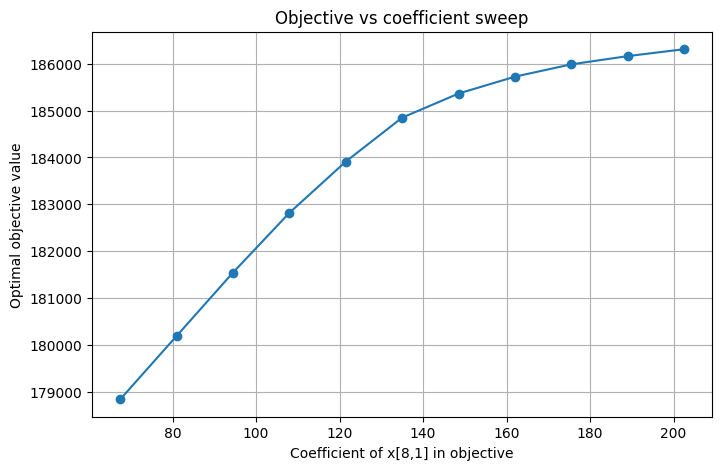

In [40]:
mm_sweep = build_sweep_model(target_i=8, target_j=1, rhs_i=0)

Solver.solve(mm_sweep, tee=False)

base_obj = float(pyo.value(mm_sweep.obj))
base_coef = float(pyo.value(mm_sweep.coef_target))

coef_values = np.linspace(base_coef * 0.5, base_coef * 1.5, 11)
obj_values = []

for cval in coef_values:
    mm_sweep.coef_target.set_value(float(cval))
    Solver.solve(mm_sweep, tee=False)
    obj_values.append(float(pyo.value(mm_sweep.obj)))

mm_sweep.coef_target.set_value(base_coef)

print("base_obj =", base_obj)
print("base_coef =", base_coef)

plt.figure(figsize=(8, 5))
plt.plot(coef_values, obj_values, marker="o")
plt.xlabel("Coefficient of x[8,1] in objective")
plt.ylabel("Optimal objective value")
plt.title("Objective vs coefficient sweep")
plt.grid(True)
plt.show()


## Summary table
Print the coefficient–objective table so the sweep results are easy to compare numerically.


In [43]:
import numpy as np
import pandas as pd

coef_base = float(pyo.value(mm_sweep.coef_target))

coef_values = np.linspace(coef_base * 0.5, coef_base * 1.5, 21)
obj_values = []

for cval in coef_values:
    mm_sweep.coef_target.set_value(float(cval))
    Solver.solve(mm_sweep, tee=False)
    obj_values.append(float(pyo.value(mm_sweep.obj)))

mm_sweep.coef_target.set_value(coef_base)

df_coef_obj = pd.DataFrame({
    "coef_x_8_1": coef_values,
    "objective": obj_values
})

display(df_coef_obj)


,coef_x_8_1,objective
0,67.50,178848.00
1,74.25,179523.00
2,81.00,180198.00
3,87.75,180873.00
4,94.50,181548.00
5,101.25,182209.50
6,108.00,182820.00
7,114.75,183372.00
8,121.50,183912.00
9,128.25,184416.00


## Sweep: RHS of sum_L1
Vary the RHS of `sum_L1` (total shortage cap for company 1) within the sensitivity range **[36.7117, 40.6410]** and plot objective vs RHS.


Chosen RHS to sweep: sum_L1
base_obj = 184848.0
base_rhs = 40.0
rhs_low, rhs_up = 36.71171171171154 40.6410256410255


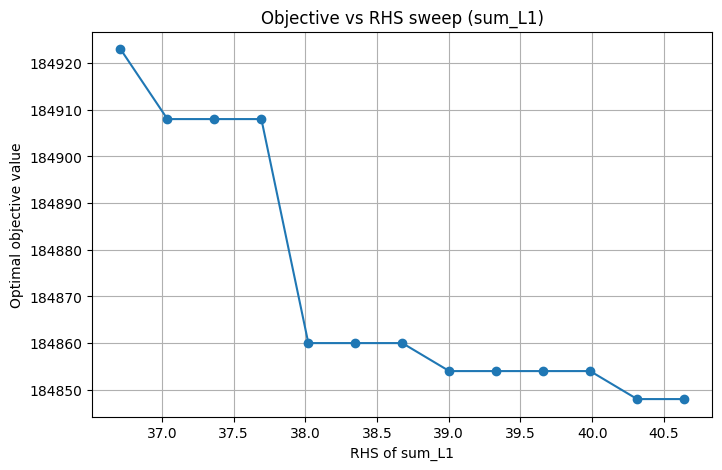

,rhs_sum_L1,obj
0,36.711712,184923.000000
1,37.039155,184908.000000
2,37.366597,184908.000000
3,37.694040,184908.000000
4,38.021483,184860.000000
5,38.348926,184860.000000
6,38.676369,184860.000000
7,39.003812,184854.000004
8,39.331254,184854.000004
9,39.658697,184854.000004


In [42]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

def build_sweep_model_rhs(rhs_name="sum_L1"):
    mm = pyo.ConcreteModel()

    mm.I = pyo.RangeSet(0, 23)
    mm.J = pyo.Set(initialize=[1, 2])

    mm.C = pyo.Param(mm.I, initialize=C)
    mm.D = pyo.Param(mm.I, mm.J, initialize=lambda m_, i, j: D[(i, j)])
    mm.Q = pyo.Set(mm.I, initialize=lambda m_, i: Q[i], within=mm.I)

    mm.x = pyo.Var(mm.I, mm.J, domain=pyo.NonNegativeIntegers, bounds=(0, 100))
    mm.L = pyo.Var(mm.I, mm.J, domain=pyo.NonNegativeIntegers, bounds=(0, 10))

    def obj_rule(m_):
        wage = sum(m_.x[i, j] * m_.C[i] for i in m_.I for j in m_.J)
        pen_L1_mid = 60 * sum(m_.L[i, 1] for i in range(7, 18))
        pen_L1_other = 30 * (sum(m_.L[i, 1] for i in range(0, 7)) + sum(m_.L[i, 1] for i in range(18, 24)))
        pen_L2 = 45 * sum(m_.L[i, 2] for i in m_.I)
        return wage + pen_L1_mid + pen_L1_other + pen_L2

    mm.obj = pyo.Objective(rule=obj_rule, sense=pyo.minimize)

    mm.cap_hire = pyo.Constraint(mm.I, rule=lambda m_, i: sum(m_.x[i, j] for j in mm.J) <= 100)
    mm.cap_work = pyo.Constraint(mm.I, rule=lambda m_, i: sum(m_.x[k, j] for k in mm.Q[i] for j in mm.J) <= 420)
    mm.shortage = pyo.Constraint(mm.I, mm.J, rule=lambda m_, i, j: m_.D[i, j] - sum(m_.x[k, j] for k in mm.Q[i]) <= m_.L[i, j])
    mm.L_cap = pyo.Constraint(mm.I, mm.J, rule=lambda m_, i, j: mm.L[i, j] <= 10)

    mm.rhs_sum_L1 = pyo.Param(initialize=40.0, mutable=True)
    mm.rhs_sum_L2 = pyo.Param(initialize=30.0, mutable=True)

    if rhs_name == "sum_L1":
        mm.sum_L1 = pyo.Constraint(expr=sum(mm.L[i, 1] for i in mm.I) <= mm.rhs_sum_L1)
        mm.sum_L2 = pyo.Constraint(expr=sum(mm.L[i, 2] for i in mm.I) <= 30)
        rhs_param = mm.rhs_sum_L1
        base_rhs = 40.0
        sa_row = df_sa_rhs.loc[df_sa_rhs["constr"] == "sum_L1"].iloc[0]
    elif rhs_name == "sum_L2":
        mm.sum_L1 = pyo.Constraint(expr=sum(mm.L[i, 1] for i in mm.I) <= 40)
        mm.sum_L2 = pyo.Constraint(expr=sum(mm.L[i, 2] for i in mm.I) <= mm.rhs_sum_L2)
        rhs_param = mm.rhs_sum_L2
        base_rhs = 30.0
        sa_row = df_sa_rhs.loc[df_sa_rhs["constr"] == "sum_L2"].iloc[0]
    else:
        raise ValueError("rhs_name must be 'sum_L1' or 'sum_L2'")

    mm.min_work = pyo.Constraint(mm.I, rule=lambda m_, i: sum(m_.x[k, j] for k in mm.Q[i] for j in mm.J) >= 80)

    return mm, rhs_param, base_rhs, sa_row

chosen = "sum_L1"
print("Chosen RHS to sweep:", chosen)

mm_rhs, rhs_param, base_rhs, sa_row = build_sweep_model_rhs(rhs_name=chosen)

Solver.solve(mm_rhs, tee=False)
base_obj = float(pyo.value(mm_rhs.obj))

low = float(sa_row["sa_rhs_low"])
up = float(sa_row["sa_rhs_up"])

rhs_values = np.linspace(low, up, 13)
obj_values = []

for r in rhs_values:
    rhs_param.set_value(float(r))
    Solver.solve(mm_rhs, tee=False)
    obj_values.append(float(pyo.value(mm_rhs.obj)))

rhs_param.set_value(base_rhs)

print("base_obj =", base_obj)
print("base_rhs =", base_rhs)
print("rhs_low, rhs_up =", low, up)

plt.figure(figsize=(8, 5))
plt.plot(rhs_values, obj_values, marker="o")
plt.xlabel("RHS of sum_L1")
plt.ylabel("Optimal objective value")
plt.title("Objective vs RHS sweep (sum_L1)")
plt.grid(True)
plt.show()

df_rhs_sweep = pd.DataFrame({"rhs_sum_L1": rhs_values, "obj": obj_values})
display(df_rhs_sweep)
